In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

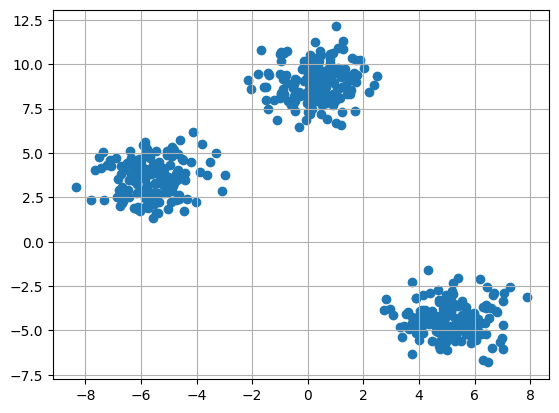

In [ ]:
X,y = make_blobs(n_samples = 500,n_features = 2,centers = 3,random_state = 23)

fig = plt.figure(0)
plt.grid(True)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [ ]:


k = 3

clusters = {}
np.random.seed(23)

for idx in range(k):
    center = 2*(2*np.random.random((X.shape[1],))-1)
    points = []
    cluster = {
        'center' : center,
        'points' : []
    }

    clusters[idx] = cluster

clusters

{0: {'center': array([0.06919154, 1.78785042]), 'points': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'points': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'points': []}}

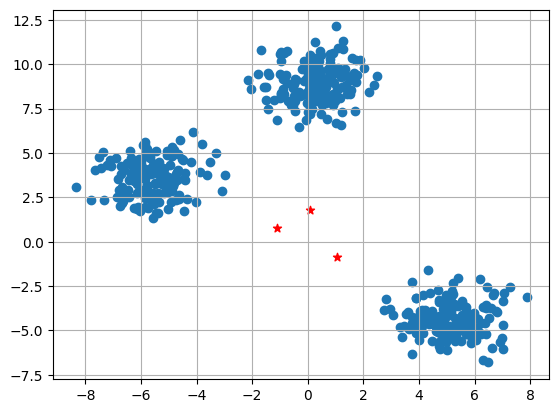

In [ ]:
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '*',c = 'red')
plt.show()

In [ ]:
def distance(p1,p2):
    return np.sqrt(np.sum((p1-p2)**2))

In [ ]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]):
        dist = []

        curr_x = X[idx]

        for i in range(k):
            dis = distance(curr_x,clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(X, clusters):
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis =0)
            clusters[i]['center'] = new_center

            clusters[i]['points'] = []
    return clusters

In [ ]:
def pred_cluster(X, clusters):
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i],clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

In [ ]:
clusters = assign_clusters(X,clusters)
clusters = update_clusters(X,clusters)
pred = pred_cluster(X,clusters)

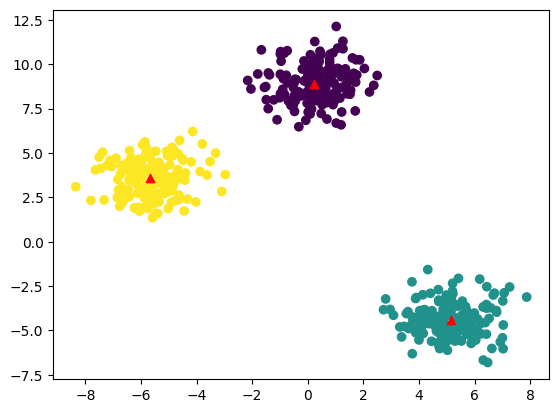

In [ ]:
plt.scatter(X[:,0],X[:,1],c = pred)
for i in clusters:
    center = clusters[i]['center']
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [ ]:
# ==========================================
# Enhanced Synthetic Dataset for K-Means Clustering
# Features: Age, Gender, Profession, Annual Income, Spending Score, Loyalty Points, Purchase Frequency
# ==========================================

import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Number of synthetic customers
n = 500

# Generate base numeric features
age = np.random.randint(18, 70, n)
income = np.random.randint(20000, 120000, n)
spending_score = np.random.randint(1, 100, n)

# Add meaningful behavioral and demographic attributes
gender = np.random.choice(['Male', 'Female'], n, p=[0.45, 0.55])

professions = ['Engineer', 'Doctor', 'Teacher', 'Entrepreneur', 'Artist', 'Student']
profession = np.random.choice(professions, n)

# Loyalty points (scaled roughly to spending)
loyalty_points = (spending_score * np.random.uniform(8, 15, n)).astype(int)

# Purchase frequency per month (correlated with spending)
purchase_frequency = np.random.normal(loc=spending_score / 10, scale=1.5).clip(1, 15).round(1)

# Create DataFrame
data = pd.DataFrame({
    'Age': age,
    'Gender': gender,
    'Profession': profession,
    'Annual Income': income,
    'Spending Score': spending_score,
    'Loyalty Points': loyalty_points,
    'Purchase Frequency': purchase_frequency
})

# Save dataset
data.to_csv('customer_data.csv', index=False)

print("✅ Enhanced dataset with demographic and behavioral features created!")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
print(data.head(10))


✅ Enhanced dataset with demographic and behavioral features created!
Rows: 500, Columns: 7
   Age  Gender    Profession  Annual Income  Spending Score  Loyalty Points  \
0   56    Male  Entrepreneur          23343              17             181   
1   69    Male        Doctor          33500              13             144   
2   46    Male        Doctor          73222              84             805   
3   32  Female       Student          49375              25             355   
4   60    Male      Engineer          29662              68             758   
5   25  Female      Engineer          36964              10             141   
6   38  Female      Engineer          79638              67             585   
7   56  Female      Engineer          93666              18             268   
8   36  Female        Artist         105067              86             954   
9   40  Female      Engineer          87215              34             283   

   Purchase Frequency  
0              

In [ ]:
# 1️⃣ Load the enhanced dataset
data = pd.read_csv('customer_data.csv')

In [ ]:
# 2️⃣ Separate numeric and categorical features
num_cols = ['Age', 'Annual Income', 'Spending Score', 'Loyalty Points', 'Purchase Frequency']
cat_cols = ['Gender', 'Profession']

In [ ]:
# ==========================================
# Step: Scale / Normalize Features for K-Means
# ==========================================

from sklearn.preprocessing import StandardScaler

# Select numeric columns you want to normalize
features = data[['Age', 'Annual Income', 'Spending Score',
                 'Loyalty Points', 'Purchase Frequency']]

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on features and transform them
scaled_features = scaler.fit_transform(features)

# Optional: Convert back to DataFrame for readability
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)

print("✅ Features scaled successfully (mean ≈ 0, std ≈ 1):")
print(scaled_df.head())


✅ Features scaled successfully (mean ≈ 0, std ≈ 1):
        Age  Annual Income  Spending Score  Loyalty Points  Purchase Frequency
0  0.784233      -1.563786       -1.093001       -1.069968           -1.223118
1  1.649686      -1.209444       -1.232521       -1.176721           -1.355261
2  0.118500       0.176318        1.243962        0.730402            0.395637
3 -0.813526      -0.655620       -0.813961       -0.567942           -1.355261
4  1.050527      -1.343338        0.685881        0.594797            0.296530


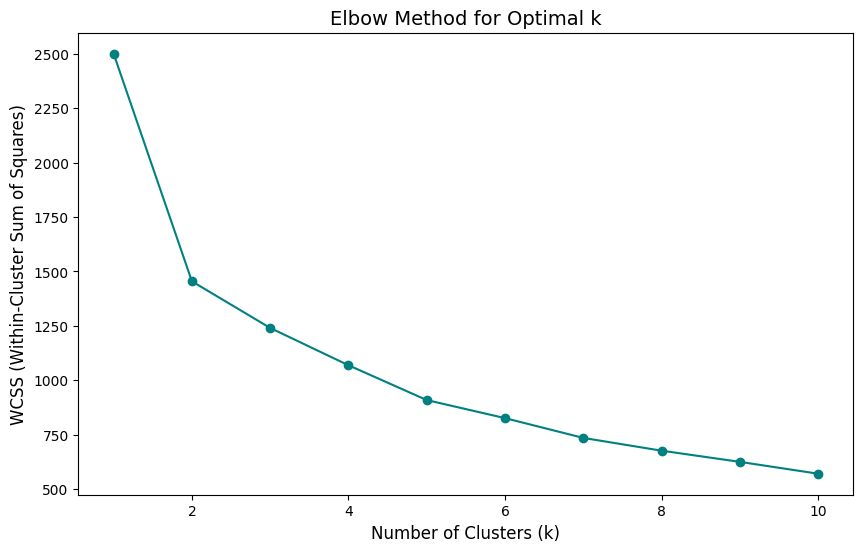

In [ ]:
# ==========================================
# Step: Elbow Method to Find Optimal Number of Clusters (k)
# ==========================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize an empty list to store WCSS (Within-Cluster Sum of Squares)
# WCSS = Sum of squared distances between each data point and its assigned cluster center.
wcss = []

# Define the maximum number of clusters (you can adjust this number if needed)
max_k = 10

# Loop through different k values (number of clusters)
for k in range(1, max_k + 1):
    # Initialize K-Means model with current k
    # random_state ensures reproducibility (same results every time you run)
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fit the K-Means model on the scaled features
    # This step assigns each point to the nearest cluster centroid
    kmeans.fit(scaled_features)

    # Append the inertia (WCSS) value for this k to the list
    # Inertia represents how internally coherent the clusters are
    wcss.append(kmeans.inertia_)

# ==========================================
# Plot the Elbow Curve
# ==========================================

plt.figure(figsize=(10, 6))  # Define figure size for better readability

# Plot number of clusters (k) on X-axis and corresponding WCSS on Y-axis
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='-', color='teal')

# Add title and axis labels for clarity
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)

# Display the plot
plt.show()


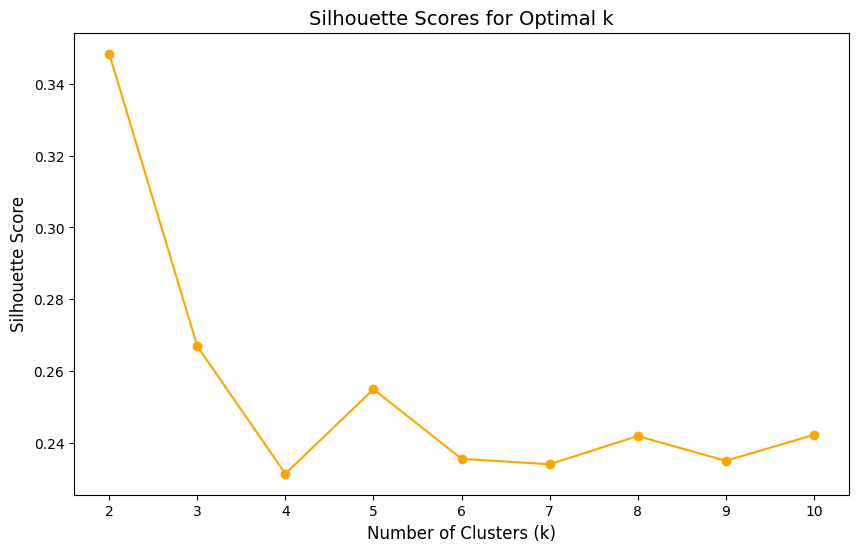

In [ ]:
# ==========================================
# Step: Silhouette Score Analysis to Validate Optimal k
# ==========================================

# Import silhouette_score metric from sklearn
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize an empty list to store silhouette scores for each k
silhouette_scores = []

# Loop through a range of cluster numbers (start from 2 because silhouette score
# is not defined for a single cluster)
for k in range(2, max_k + 1):

    # Initialize K-Means model with current number of clusters (k)
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fit the model on scaled features
    kmeans.fit(scaled_features)

    # Compute the silhouette score for this clustering
    # It measures how well each data point fits into its cluster compared to other clusters
    score = silhouette_score(scaled_features, kmeans.labels_)

    # Append the score to the list
    silhouette_scores.append(score)

# ==========================================
# Plot Silhouette Scores
# ==========================================

plt.figure(figsize=(10, 6))  # Define figure size

# Plot number of clusters (k) on X-axis and silhouette score on Y-axis
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', color='orange', linestyle='-')

# Add titles and axis labels for clarity
plt.title('Silhouette Scores for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)

# Display the plot
plt.show()


In [ ]:
# ==========================================
# Step 3 – Elbow Method (Numerical Output Only)
# ==========================================

from sklearn.cluster import KMeans

# Initialize list to store WCSS values
wcss = []

# Define range for k
max_k = 10

# Loop through k values and compute WCSS
for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Display WCSS values in a neat table
print("📊 WCSS (Within-Cluster Sum of Squares) for different k values:\n")
for i, val in enumerate(wcss, start=1):
    print(f"k = {i:<2} → WCSS = {val:.2f}")

# Optionally, you can identify where WCSS starts flattening manually.
# The 'elbow' (best k) is typically where WCSS drop slows down significantly.


📊 WCSS (Within-Cluster Sum of Squares) for different k values:

k = 1  → WCSS = 2500.00
k = 2  → WCSS = 1454.84
k = 3  → WCSS = 1240.75
k = 4  → WCSS = 1069.44
k = 5  → WCSS = 909.57
k = 6  → WCSS = 826.67
k = 7  → WCSS = 735.83
k = 8  → WCSS = 677.17
k = 9  → WCSS = 625.85
k = 10 → WCSS = 571.42


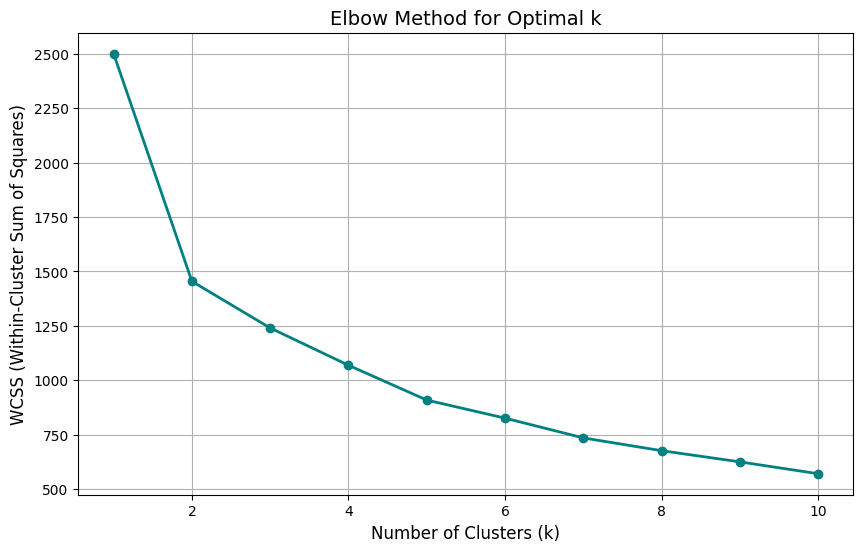

In [ ]:
# 4️⃣ Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', color='teal', linewidth=2)
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
# ==========================================
# Step 1 – Calculate Silhouette Scores for Different k Values
# ==========================================

# Import required libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1️⃣  Create an empty list to store silhouette scores for each k
silhouette_scores = []

# 2️⃣  Define the range of cluster numbers to test (start from 2 since k=1 is invalid)
max_k = 10   # You can adjust this range depending on your dataset size
k_values = range(2, max_k + 1)

# 3️⃣  Loop through each k value
for k in k_values:
    # Initialize KMeans model with current k
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fit the model on the scaled data
    kmeans.fit(scaled_features)

    # Predict cluster labels
    labels = kmeans.labels_

    # Compute the Silhouette Score for this clustering
    # It measures how similar each point is to its own cluster vs other clusters
    score = silhouette_score(scaled_features, labels)

    # Append the score to our list
    silhouette_scores.append(score)

    # Print progress and score for transparency
    print(f"k = {k:<2} → Silhouette Score = {score:.3f}")

# 4️⃣  Identify the best k (highest silhouette score)
best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"\n⭐ Best k based on Silhouette Score: {best_k}")
print(f"💡 Highest Silhouette Score: {max(silhouette_scores):.3f}")


k = 2  → Silhouette Score = 0.348
k = 3  → Silhouette Score = 0.267
k = 4  → Silhouette Score = 0.231
k = 5  → Silhouette Score = 0.255
k = 6  → Silhouette Score = 0.236
k = 7  → Silhouette Score = 0.234
k = 8  → Silhouette Score = 0.242
k = 9  → Silhouette Score = 0.235
k = 10 → Silhouette Score = 0.242

⭐ Best k based on Silhouette Score: 2
💡 Highest Silhouette Score: 0.348


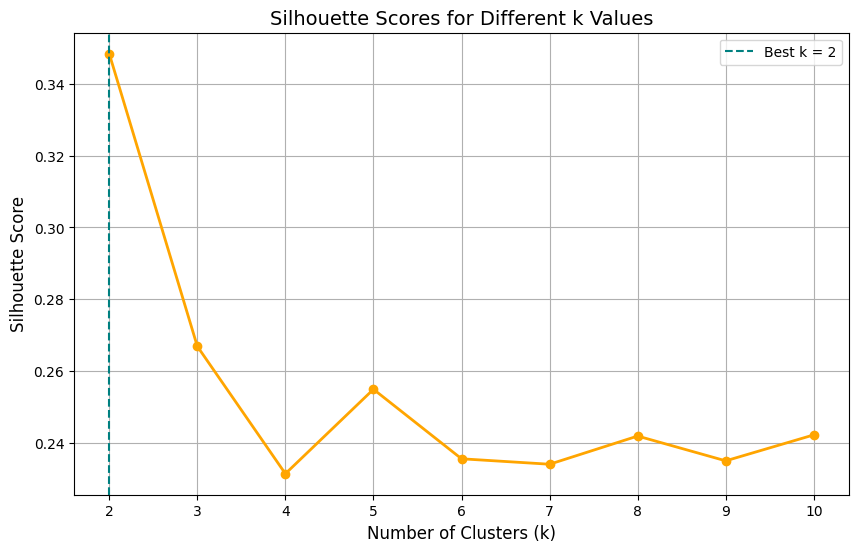

In [ ]:
# ==========================================
# Step 2 – Visualize Silhouette Scores
# ==========================================

import matplotlib.pyplot as plt

# 1️⃣  Plot the silhouette scores for all tested k values
plt.figure(figsize=(10, 6))

# Draw line plot showing how the Silhouette Score changes as k increases
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', color='orange', linewidth=2)

# 2️⃣  Add chart titles and labels
plt.title('Silhouette Scores for Different k Values', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)

# 3️⃣  Highlight the best k (maximum score)
best_score = max(silhouette_scores)
best_k = range(2, max_k + 1)[silhouette_scores.index(best_score)]
plt.axvline(best_k, linestyle='--', color='teal', label=f'Best k = {best_k}')
plt.legend()

# 4️⃣  Add grid and show the plot
plt.grid(True)
plt.show()


⭐ Best k (from Silhouette): 3  |  Score: 0.348


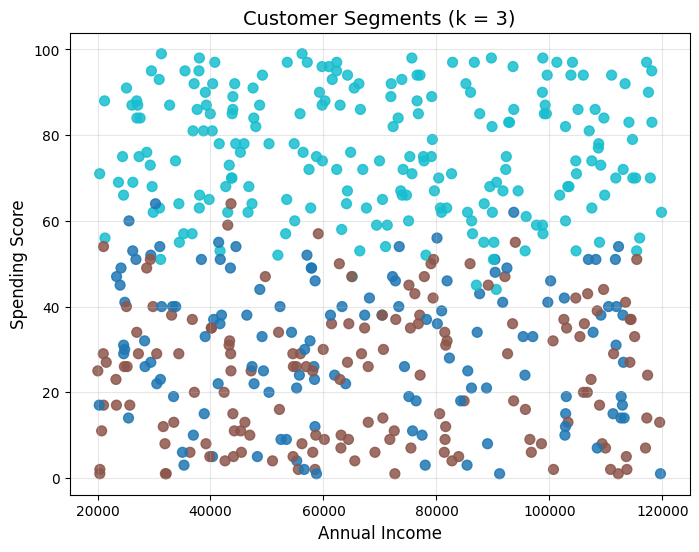

📊 Cluster Summary (feature means by cluster):

          Age  Annual Income  Spending Score  Loyalty Points  \
Cluster                                                        
0        29.2        66231.7            31.1           345.4   
1        56.1        67422.9            24.0           272.4   
2        44.7        69875.8            76.3           878.1   

         Purchase Frequency  
Cluster                      
0                       3.4  
1                       2.6  
2                       7.9  

✅ Saved labeled dataset → 'customer_data_labeled.csv'


In [ ]:
# ==========================================
# Step 3 – Fit Final K-Means and Visualize/Summarize
# ==========================================

import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1️⃣  Get best k from the silhouette scores (reliable even if you re-run this cell)
best_score = max(silhouette_scores)
best_k = list(range(3, max_k + 1))[silhouette_scores.index(best_score)]
print(f"⭐ Best k (from Silhouette): {best_k}  |  Score: {best_score:.3f}")

# 2️⃣  Fit final K-Means using the best k (use n_init for stability)
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Fit on the scaled features and get cluster labels
final_labels = final_kmeans.fit_predict(scaled_features)

# 3️⃣  Attach cluster labels back to the original DataFrame
#     (Assumes `data` is your original DataFrame with columns like Age, Annual Income, etc.)
data['Cluster'] = final_labels

# 4️⃣  Visualize clusters in an intuitive 2D plane
#     We use 'Annual Income' vs 'Spending Score' which is easy to interpret for marketing
plt.figure(figsize=(8, 6))
plt.scatter(
    data['Annual Income'],
    data['Spending Score'],
    c=data['Cluster'],
    cmap='tab10',
    s=50,
    alpha=0.85
)
plt.title(f'Customer Segments (k = {best_k})', fontsize=14)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 5️⃣  Print a compact cluster summary for quick insight
summary_cols = [c for c in ['Age', 'Annual Income', 'Spending Score', 'Loyalty Points', 'Purchase Frequency'] if c in data.columns]
cluster_summary = (data
                   .groupby('Cluster')[summary_cols]
                   .mean()
                   .round(1))
print("📊 Cluster Summary (feature means by cluster):\n")
print(cluster_summary)

# 6️⃣  (Optional) Save labeled dataset for downstream use (segmentation, targeting, etc.)
data.to_csv('customer_data_labeled.csv', index=False)
print("\n✅ Saved labeled dataset → 'customer_data_labeled.csv'")


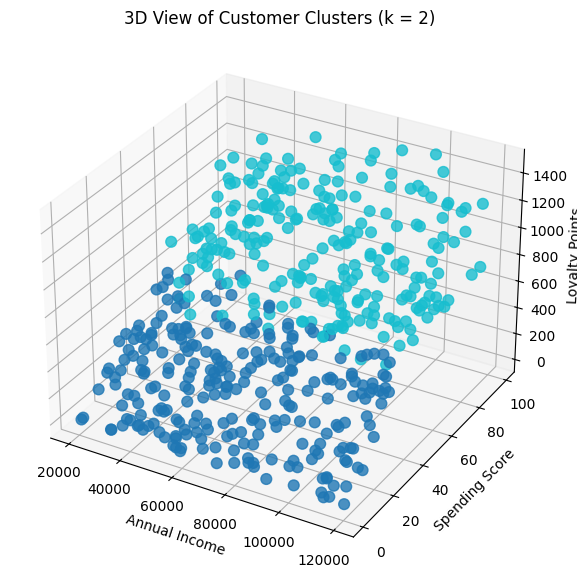

In [ ]:
# ==========================================
# Step 4 – 3D Visualization of Clusters
# ==========================================

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Pick 3 meaningful dimensions to visualize
x_col = 'Annual Income'
y_col = 'Spending Score'
z_col = 'Loyalty Points'

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot: color = cluster label
ax.scatter(
    data[x_col],
    data[y_col],
    data[z_col],
    c=data['Cluster'],
    cmap='tab10',
    s=60,
    alpha=0.8
)

# Label axes
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_zlabel(z_col)
ax.set_title(f'3D View of Customer Clusters (k = {best_k})')

plt.show()
